![Banner](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/prompt_engineering_how_they_work_banner.png)


# Prompt Engineering: How They Work

**Abstract.** The previous notebook ([How LLMs Work](llms_how_they_work.ipynb)) built the full forward-pass pipeline from tokenization through generation. This notebook picks up exactly where that one left off: once the substrate is in place, *how does a prompt actually steer a reply?* We develop the mechanics of prompt conditioning, in-context learning, chain-of-thought reasoning, self-consistency, and the bridge from prompting into agentic loops. Every concept is paired with a runnable demo on SmolLM2-135M. No GPU or API keys are required.

The aim is not merely to define the vocabulary, but to make the machinery legible. Wherever possible, the mathematics is tied to something you can inspect in a real model.

This is **Part 2 of 4** in a series on large language models:

1. [How LLMs Work](llms_how_they_work.ipynb), architecture, training objective, and inference pipeline.
2. **Prompt Engineering** (this notebook), how prompts steer outputs, in-context learning, chain-of-thought, and reasoning-time compute.
3. [How Agents Work](agents_how_they_work.ipynb), tool use, orchestration, memory, evaluation, and agentic loops.
4. [Retrieval-Augmented Generation](rag_how_they_work.ipynb), embeddings, vector search, chunking, RAG pipelines, evaluation, and agentic retrieval.


# Introduction

By the end of the companion architecture notebook, we had a fully wired autoregressive model: tokens go in, logits come out, and a sampling strategy turns those logits into text. But that machinery leaves one question unresolved: how does a prompt actually *steer* a reply? Why does adding "Let's think step by step" sometimes change the answer? Why can three examples in the context teach the model a new task without altering a single parameter?

The first half develops prompt conditioning as a distributional phenomenon (not a feature, not an API parameter, but a consequence of how attention works over the full sequence). The second half turns that observation into a broader discussion of reasoning-time compute: chain-of-thought, self-consistency, and the bridge from prompting into agents.


# Notebook Setup


In [1]:
!pip install torch transformers numpy pandas matplotlib seaborn scikit-learn --quiet


In [2]:
import json, sys, math, warnings, platform
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import transformers as _tf
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(42)
torch.manual_seed(42)

print(f"PyTorch {torch.__version__}  |  Transformers {_tf.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")


C:\Users\adamd\conda_envs\deeplearn\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.11.0+cpu  |  Transformers 5.6.2
Device: cpu


## Model Loading

We load **SmolLM2-135M** (base variant only). The base model is an unconditional next-token predictor. That's exactly what we need to study how prompts shape the output distribution without the confound of instruction-following alignment.


In [3]:
BASE_ID = "HuggingFaceTB/SmolLM2-135M"

tokenizer = AutoTokenizer.from_pretrained(BASE_ID)
model_base = AutoModelForCausalLM.from_pretrained(
    BASE_ID, dtype=torch.float32, attn_implementation="eager",
)
model_base.eval()
print(f"Tokenizer vocab size: {tokenizer.vocab_size:,}")
print(f"Base model parameters: {sum(p.numel() for p in model_base.parameters()):,}")


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights:  37%|███▋      | 101/272 [00:00<00:00, 1006.42it/s]

Loading weights:  78%|███████▊  | 211/272 [00:00<00:00, 1042.74it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 1065.81it/s]

Tokenizer vocab size: 49,152
Base model parameters: 134,515,008


# The Prompt as a Conditional Distribution

An autoregressive LLM defines a joint distribution over token sequences by factorising it into a chain of conditionals:

$$P(y_1, y_2, \dots, y_T) = \prod_{t=1}^{T} P(y_t \mid y_{<t})$$

When we supply a prompt $x = (x_1, \dots, x_n)$, every generated token is conditioned on *all* prompt tokens plus all previously generated tokens:

$$P(y_t \mid x_1, \dots, x_n, y_1, \dots, y_{t-1})$$

The prompt is not metadata, not an API parameter in disguise, and not a privileged instruction register. It is simply part of the sequence. That is precisely why it is so powerful: changing even one token in $x$ perturbs the hidden-state geometry seen by every later token, and therefore changes the entire output distribution.

The important conceptual shift is this: a prompt does not *tell* the model what to do in any symbolic sense. It changes which continuations become probable. What practitioners call prompt engineering is, at bottom, the craft of reshaping $P(y \mid x)$ so that the model's high-probability completions align with the behaviour one wants.

## Why This Matters Mechanistically

At each layer $\ell$, the hidden state $h_t^{(\ell)}$ of a generated token $y_t$ is computed via self-attention over *all* preceding positions: including the prompt tokens. So the prompt influences $y_t$ through every attention head across every layer:

$$h_t^{(\ell)} = h_t^{(\ell-1)} + \text{Attn}^{(\ell)}(h_t^{(\ell-1)}, \; \{h_j^{(\ell-1)}\}_{j \leq t})$$

where $j$ ranges over both prompt positions and previously generated positions. In other words, the prompt is already "inside" the residual stream before the first answer token appears.


## Demo 1: How Prompts Shift the Output Distribution

We feed SmolLM2 different prompts that all end at the same decision point, and compare the resulting next-token distributions. This makes the conditioning effect visible.


=== How Prompts Seed the Reply ===

  Prompt: 'The answer is'
            that  0.1304
               ,  0.0891
               :  0.0567
             yes  0.0508
              no  0.0393

  Prompt: 'What is 12 + 7? The answer is'
                  0.6536
               :  0.0654
               (  0.0212
               ,  0.0212
               "  0.0148



  Prompt: 'What is the capital of Japan? The answer is'
           Tokyo  0.0958
               :  0.0899
             the  0.0537
           Japan  0.0371
               ,  0.0269

  Prompt: 'The movie was terrible. The review said the answer is'
               "  0.1825
               “  0.0623
                  0.0457
               a  0.0402
             yes  0.0332

  Prompt: 'def add(a, b): return a + b  # The answer is'
             the  0.1601
               a  0.1460
                  0.1145
              an  0.0250
          always  0.0224



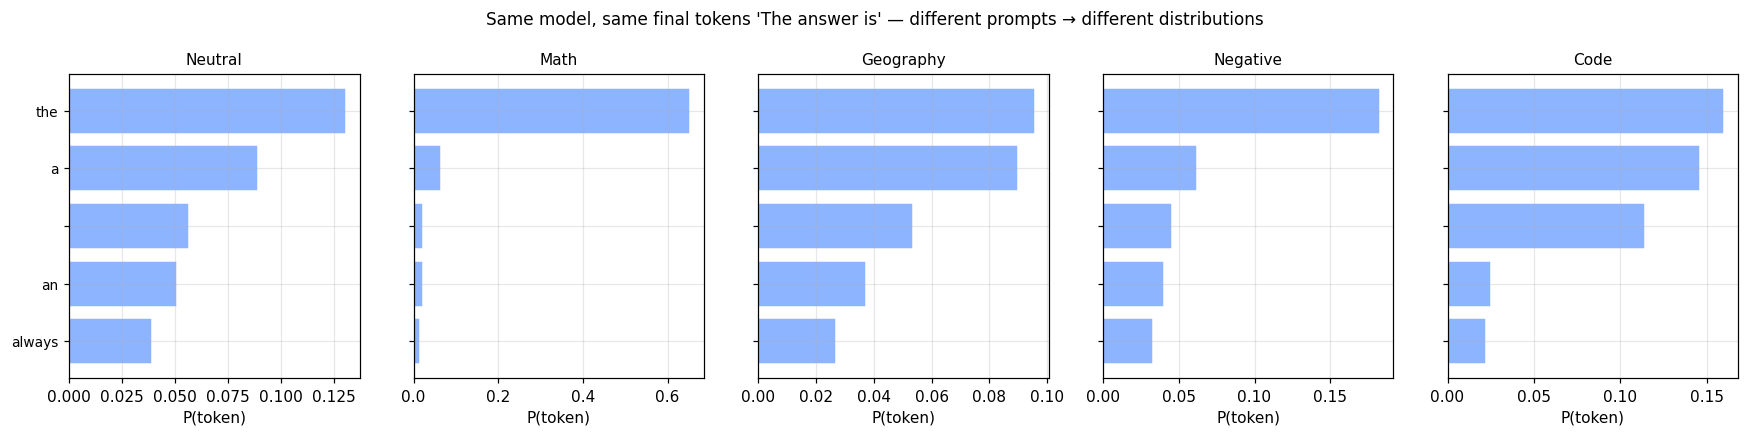

The model weights are identical across all five prompts.
The prompt alone shifts the distribution. No fine-tuning, no extra parameters.


In [4]:
prompts = {
    "Neutral":     "The answer is",
    "Math":        "What is 12 + 7? The answer is",
    "Geography":   "What is the capital of Japan? The answer is",
    "Negative":    "The movie was terrible. The review said the answer is",
    "Code":        "def add(a, b): return a + b  # The answer is",
}

print("=== How Prompts Seed the Reply ===\n")
all_top5 = {}

for label, prompt in prompts.items():
    ids = tokenizer.encode(prompt, return_tensors="pt")
    with torch.no_grad():
        logits = model_base(ids).logits[0, -1].float()
    probs = torch.softmax(logits, dim=-1)
    top5_idx = torch.argsort(probs, descending=True)[:5]
    top5 = [(tokenizer.decode(idx.item()).strip(), probs[idx].item()) for idx in top5_idx]
    all_top5[label] = top5
    print(f"  Prompt: {prompt!r}")
    for tok, p in top5:
        print(f"    {tok:>12s}  {p:.4f}")
    print()

# Visualization: side-by-side distributions
fig, axes = plt.subplots(1, len(prompts), figsize=(16, 4), sharey=True)
for ax, (label, top5) in zip(axes, all_top5.items()):
    tokens, probs_list = zip(*top5)
    ax.barh(range(5), probs_list, color="#8db4ff", edgecolor="white")
    ax.set_yticks(range(5))
    ax.set_yticklabels(tokens, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("P(token)")
    ax.set_title(label, fontsize=10)
fig.suptitle("Same model, same final tokens 'The answer is', different prompts → different distributions", fontsize=11)
plt.tight_layout()
plt.show()

print("The model weights are identical across all five prompts.")
print("The prompt alone shifts the distribution. No fine-tuning, no extra parameters.")


# In-Context Learning vs Fine-Tuning

Once prompt-conditioning is understood, **in-context learning** (ICL) stops looking magical and starts looking like a special case of conditioning.

## In-Context Learning (ICL)

Brown et al. (2020) showed that large language models can often infer a task *at inference time* from a few examples placed directly in the prompt:

```
Translate English to French:
cat → chat
dog → chien
house →
```

The model outputs "maison": without any gradient update. The examples $(x_i, y_i)$ are not training data in the usual sense; they are simply more context, and they therefore reshape the conditional distribution:

$$P(y \mid x_1, y_1, \dots, x_k, y_k, x_{\text{query}})$$

One helpful mental model is that the network uses attention to search the context for a local template: *what kind of input does this resemble, and what sort of completion followed it before?* Mechanistic interpretability work (Olsson et al., 2022) identifies specific "induction head" behaviour consistent with this copy-and-continue story.

**How many examples?** Empirically:
- **Zero-shot**: just the instruction (often sufficient for instruct models).
- **Few-shot** (1–5): dramatic improvement on tasks the model has seen during pretraining.
- **Many-shot** (10–50): marginal gains; may hit context limits.

The catch is brittleness. Order matters. Formatting matters. Label choice matters. Even when the task is easy, the route through context space can be surprisingly fragile.

## Fine-Tuning

Fine-tuning solves a different problem. Instead of borrowing temporary structure from the prompt, it changes the weights $\theta$ themselves on a task-specific dataset $\mathcal{D}$:

$$\theta^* = \arg\min_{\theta} \sum_{(x,y) \in \mathcal{D}} -\log P_\theta(y \mid x)$$

This *permanently* changes the conditional distribution for future inputs. The task prior is no longer carried in the prompt; it is stored in the model parameters.

| | In-Context Learning | Fine-Tuning |
|---|---|---|
| **What changes** | Prompt (input) | Weights ($\theta$) |
| **When it happens** | Inference time | Training time |
| **Persistence** | Per-conversation only | Permanent |
| **Data needed** | 0–50 examples in prompt | 100s–1000s of labelled examples |
| **Context cost** | Uses context window | No runtime cost |
| **Generalisation** | Brittle; format-sensitive | Dependable if data is representative |
| **Cost** | Cheap per query (just tokens) | Expensive once (GPU hours) |

The practical distinction is therefore simple:
- **ICL** when you have few examples, the task is simple, or you need flexibility across tasks.
- **Fine-tuning** when you have labelled data, need consistent performance, or the task diverges from pretraining distribution.
- **Both** (fine-tune + few-shot) for maximum performance on domain-specific tasks.


## Demo 2: In-Context Learning: Few-Shot vs Zero-Shot

This demo keeps the task deliberately small. The point is not to benchmark SmolLM2 as a classifier, but to show that examples in the prompt can change the model's preference over candidate label completions even when the weights remain fixed.


=== In-Context Learning: Zero-Shot vs Few-Shot ===

  Zero-shot:
    Prompt length: 23 tokens
    Candidate continuation scores (mean log-prob per token):
          positive  mean= -4.605  total= -4.605  tokens=1
          negative  mean= -4.746  total= -4.746  tokens=1
           neutral  mean= -7.520  total= -7.520  tokens=1



  Few-shot (3 examples):
    Prompt length: 63 tokens
    Candidate continuation scores (mean log-prob per token):
          negative  mean= -0.566  total= -0.566  tokens=1
          positive  mean= -1.767  total= -1.767  tokens=1
           neutral  mean= -3.131  total= -3.131  tokens=1



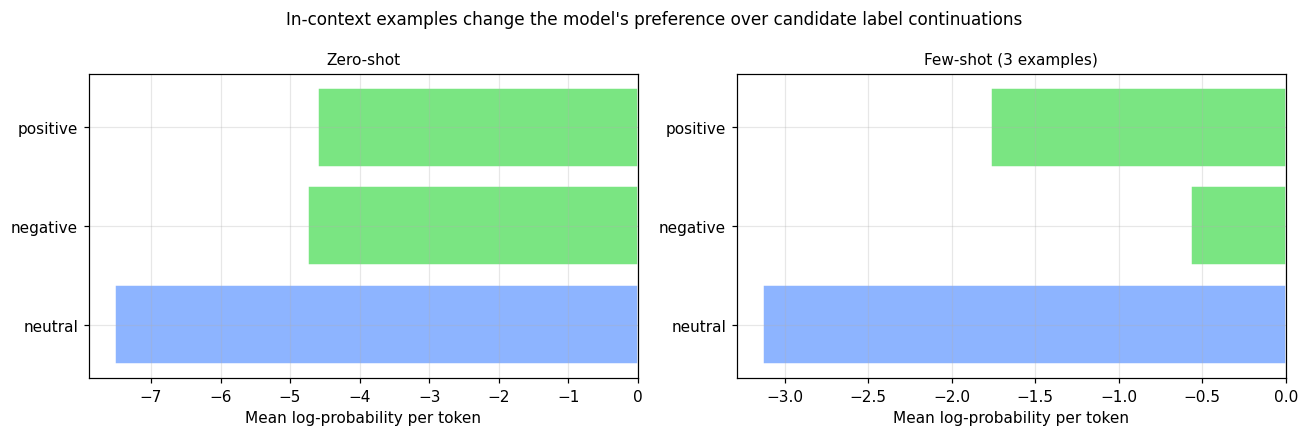

Same model, same weights. The only difference is the examples in the prompt.
Here we score whole label continuations rather than just the first token, which is the cleaner quantity.
The few-shot prompt changes which completion the model finds most plausible.


In [5]:
zero_shot_prompt = 'Classify the sentiment as positive or negative.\nText: "The battery life is awful."\nSentiment:'
few_shot_prompt = (
    'Classify the sentiment as positive or negative.\n'
    'Text: "I love this phone!" Sentiment: positive\n'
    'Text: "Worst purchase ever." Sentiment: negative\n'
    'Text: "Amazing camera quality." Sentiment: positive\n'
    'Text: "The battery life is awful."\nSentiment:'
)

candidate_labels = [" positive", " negative", " neutral"]

def continuation_logprob(prompt_text, continuation_text):
    prompt_ids = tokenizer.encode(prompt_text, add_special_tokens=False)
    continuation_ids = tokenizer.encode(continuation_text, add_special_tokens=False)
    full_ids = torch.tensor([prompt_ids + continuation_ids])
    with torch.no_grad():
        logits = model_base(full_ids).logits[0]

    log_probs = []
    start = len(prompt_ids)
    for pos, tok_id in enumerate(continuation_ids, start=start):
        prev_pos = pos - 1
        token_logprob = torch.log_softmax(logits[prev_pos], dim=-1)[tok_id].item()
        log_probs.append(token_logprob)

    total_lp = float(np.sum(log_probs))
    mean_lp = total_lp / max(len(continuation_ids), 1)
    return total_lp, mean_lp, continuation_ids

print("=== In-Context Learning: Zero-Shot vs Few-Shot ===\n")
for label, prompt in [("Zero-shot", zero_shot_prompt), ("Few-shot (3 examples)", few_shot_prompt)]:
    rows = []
    for cand in candidate_labels:
        total_lp, mean_lp, cont_ids = continuation_logprob(prompt, cand)
        rows.append((cand, total_lp, mean_lp, len(cont_ids)))

    rows.sort(key=lambda x: -x[2])
    ids = tokenizer.encode(prompt, return_tensors="pt")
    print(f"  {label}:")
    print(f"    Prompt length: {ids.shape[1]} tokens")
    print(f"    Candidate continuation scores (mean log-prob per token):")
    for cand, total_lp, mean_lp, n_tok in rows:
        print(f"      {cand:>12s}  mean={mean_lp:>7.3f}  total={total_lp:>7.3f}  tokens={n_tok}")
    print()

# Visual comparison of class-label preferences
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, prompt) in zip(axes, [("Zero-shot", zero_shot_prompt),
                                       ("Few-shot (3 examples)", few_shot_prompt)]):
    score_rows = []
    for cand in candidate_labels:
        _, mean_lp, _n = continuation_logprob(prompt, cand)
        score_rows.append((cand.strip(), mean_lp))
    labels_plot, vals_plot = zip(*score_rows)
    colors_icl = ["#7ae582" if t in ("positive", "negative") else "#8db4ff" for t in labels_plot]
    ax.barh(range(len(labels_plot)), vals_plot, color=colors_icl, edgecolor="white")
    ax.set_yticks(range(len(labels_plot)))
    ax.set_yticklabels(labels_plot, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("Mean log-probability per token")
    ax.set_title(label, fontsize=10)
fig.suptitle("In-context examples change the model's preference over candidate label continuations", fontsize=11)
plt.tight_layout()
plt.show()

print("Same model, same weights. The only difference is the examples in the prompt.")
print("Here we score whole label continuations rather than just the first token, which is the cleaner quantity.")
print("The few-shot prompt changes which completion the model finds most plausible.")


# How Chain-of-Thought Works Mechanistically

The crucial step is now easy to state. If prompt tokens steer the distribution, then model-generated reasoning tokens can do the same. Chain-of-thought is not magic layered on top of the model; it is the same conditioning mechanism, turned back onto the model's own intermediate output.

When the model generates "Let's think step by step. 37 × 50 = 1850. 37 × 2 = 74. 1850 − 74 =", the final token distribution is conditioned on the entire chain:

$$P(y_T \mid \underbrace{x_1, \dots, x_n}_{\text{user prompt}}, \underbrace{y_1, \dots, y_{T-1}}_{\text{CoT trace}})$$

Each generated token adds to the residual stream that subsequent tokens attend to. In that sense, the CoT trace functions as a scratchpad embedded inside the sequence itself. It does three jobs at once:

1. **Decomposes** a complex problem into sub-problems (each sub-answer occupies its own token positions).
2. **Stores intermediate results** in the sequence itself (since the model has no external memory).
3. **Provides extra layers of computation**: each new token gets $N$ full transformer layers of processing.

A transformer with $N = 30$ layers generating $T = 20$ CoT tokens effectively performs $30 \times 20 = 600$ serial attention-plus-FFN stages, compared with $30$ for a one-token answer. This is the mechanical reason CoT can help: it turns a depth-bounded computation into a length-extended one.

## "Thinking" Models

Some reasoning models take this logic further by allocating a **dedicated reasoning-token budget** before producing the final answer. Those tokens are best understood as extra serial computation steps, not as evidence that the model has acquired a separate faculty called "thinking."

However, the exact mechanism varies by provider and model family:

| Aspect | Varies across models |
|---|---|
| **Visibility** | Some expose the full chain; others show a summary; some hide it entirely |
| **Training** | Some are trained with RL using outcome supervision (the model is rewarded only when its final answer is correct, regardless of how it reasoned); others use SFT on long reasoning chains, sometimes combined with RL or distilled from a stronger reasoner |
| **Token budget** | Some use fixed budgets; others allocate dynamically based on difficulty |
| **Cost** | Thinking tokens are billed but may not be visible in the response |

The durable insight is modest but important: reasoning is, in part, a budget-allocation problem. If one gives the model more intermediate positions in which to compute, some classes of problems become easier.


## Demo 3: How CoT Tokens Shift Downstream Predictions

We compare the next-token distribution with and without intermediate reasoning tokens,
showing how the CoT trace changes what the model predicts.


=== How CoT Tokens Shift Predictions ===

  Direct (no CoT):
    Prompt: 'What is 12 + 15? The answer is'
    Tokens in prompt: 13
                0.6640  ██████████████████████████████████████████████████████████████████
             :  0.0621  ██████
             (  0.0244  ██
             ,  0.0204  ██
             -  0.0139  █

  With CoT trace:
    Prompt: 'What is 12 + 15? Let me think step by step. 12 + 15 = 12 + 10 + 5 = 22 + 5 = 27. The answer is'
    Tokens in prompt: 50
                0.7151  ███████████████████████████████████████████████████████████████████████
       correct  0.0326  ███
           the  0.0213  ██
             :  0.0167  █
           not  0.0137  █



  Entropy (Direct):  2.13 nats  (less certain)
  Entropy (CoT):     1.94 nats  (more certain)
  The CoT trace narrows the distribution toward the correct answer.



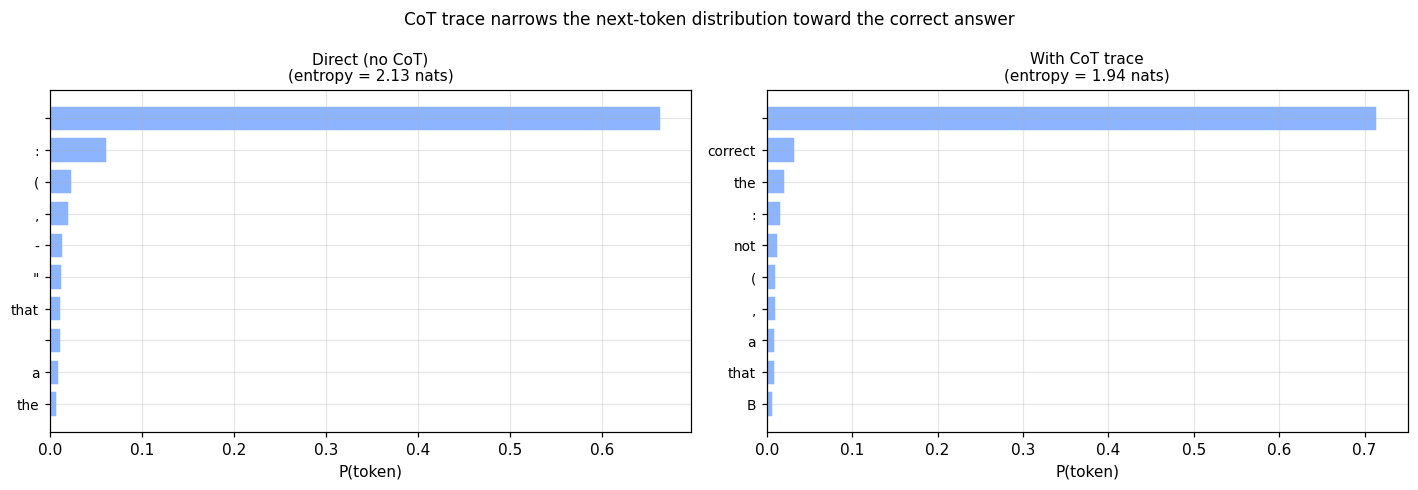

Without CoT, the model spreads probability across many plausible continuations.
With CoT, the intermediate tokens 'lock in' the reasoning, concentrating probability on '27'.
This is why CoT works: each intermediate token constrains the distribution for all subsequent tokens.


In [6]:
prompt_direct = "What is 12 + 15? The answer is"
prompt_cot = "What is 12 + 15? Let me think step by step. 12 + 15 = 12 + 10 + 5 = 22 + 5 = 27. The answer is"

print("=== How CoT Tokens Shift Predictions ===\n")

distributions = {}
for label, prompt in [("Direct (no CoT)", prompt_direct),
                      ("With CoT trace", prompt_cot)]:
    ids = tokenizer.encode(prompt, return_tensors="pt")
    with torch.no_grad():
        logits = model_base(ids).logits[0, -1].float()
    probs = torch.softmax(logits, dim=-1)
    top10_idx = torch.argsort(probs, descending=True)[:10]
    top10 = [(tokenizer.decode(i.item()).strip(), probs[i].item()) for i in top10_idx]
    distributions[label] = top10

    print(f"  {label}:")
    print(f"    Prompt: {prompt!r}")
    print(f"    Tokens in prompt: {ids.shape[1]}")
    for tok, p in top10[:5]:
        bar = "█" * int(p * 100)
        print(f"      {tok:>8s}  {p:.4f}  {bar}")
    print()

# Entropy comparison
entropies = {}
for label, prompt in [("Direct", prompt_direct), ("CoT", prompt_cot)]:
    ids = tokenizer.encode(prompt, return_tensors="pt")
    with torch.no_grad():
        logits = model_base(ids).logits[0, -1].float()
    probs = torch.softmax(logits, dim=-1)
    ent = -(probs * torch.log(probs + 1e-12)).sum().item()
    entropies[label] = ent

print(f"  Entropy (Direct):  {entropies['Direct']:.2f} nats  (less certain)")
print(f"  Entropy (CoT):     {entropies['CoT']:.2f} nats  (more certain)")
print(f"  The CoT trace narrows the distribution toward the correct answer.\n")

# Visualization
ent_keys = ["Direct", "CoT"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (label, top10), ek in zip(axes, distributions.items(), ent_keys):
    tokens, probs_vals = zip(*top10)
    colors_cot = ["#7ae582" if t.strip() in ("27",) else "#8db4ff" for t in tokens]
    ax.barh(range(len(tokens)), probs_vals, color=colors_cot, edgecolor="white")
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("P(token)")
    ax.set_title(f"{label}\n(entropy = {entropies[ek]:.2f} nats)", fontsize=10)
fig.suptitle("CoT trace narrows the next-token distribution toward the correct answer", fontsize=11)
plt.tight_layout()
plt.show()

print("Without CoT, the model spreads probability across many plausible continuations.")
print("With CoT, the intermediate tokens 'lock in' the reasoning, concentrating probability on '27'.")
print("This is why CoT works: each intermediate token constrains the distribution for all subsequent tokens.")


# Chain-of-Thought Prompting

A single forward pass is often too shallow for tasks whose solution is naturally multi-step. If we ask for the answer to "37 × 48" in one jump, the model must compress decomposition, arithmetic, and answer formatting into one continuation. Wei et al. (2022) showed that performance improves markedly when the model is instead prompted to externalise intermediate reasoning steps: the now-standard **chain-of-thought** (CoT) pattern.

The model generates a trace like:
```
Q: What is 37 × 48?
A: Let me think step by step.
   37 × 48 = 37 × 50 − 37 × 2
           = 1850 − 74
           = 1776.
```

The idea is simple but subtle. Each intermediate token becomes part of the context for the next one, so the model can use its own output as a temporary workspace. Mechanistically, this means the fixed transformer depth is effectively recycled across more positions. CoT is therefore not mysterious extra intelligence; it is a way of buying more serial computation with tokens.

The limitation is equally important. CoT does not guarantee correctness. It can just as easily produce a fluent rationale for a wrong answer. More visible reasoning is not the same thing as more faithful reasoning.


# Self-Consistency: Voting Over Multiple Chains

Once CoT is available, the next natural question is whether we should trust any single reasoning trace. Often the answer is no. Wang et al. (2022) proposed **self-consistency**: sample multiple chains, extract the final answer from each, and let agreement carry evidential weight.

1. Sample $N$ CoT completions $c_1, \dots, c_N$ from the model (with temperature $\tau > 0$).
2. Extract the final answer from each chain: $a_i = \text{answer}(c_i)$.
3. Take the **majority vote**:

$$
\hat{a} = \arg\max_{a} \sum_{i=1}^{N} \mathbf{1}[\text{answer}(c_i) = a].
$$

This is ensemble reasoning at inference time. Diversity across traces can rescue the system from an unlucky path, especially on problems with one clear right answer. The cost, of course, scales roughly linearly with the number of samples. The gains are front-loaded: the jump from one sample to five is often meaningful; the jump from fifteen to twenty is usually not. The original paper reports gains of roughly +18 percentage points on GSM8K, +11 on SVAMP, and +12 on AQuA over greedy CoT, depending on model scale.

Self-consistency is attractive because it is simple and model-agnostic. But it has a sharp limitation: if the model is systematically drawn toward the wrong answer, majority vote will stabilise the mistake rather than repair it.


## Demo 4: Self-Consistency Simulation

We simulate self-consistency by generating multiple completions from SmolLM2 with different
random seeds, extracting an answer token from each, and computing the majority vote.


=== Self-Consistency: 'The capital of France is' ===

τ      Samples                                                      Majority vote   Agreement
----------------------------------------------------------------------------------------------------
0.5    the, the, the, the, the, the, the, the, the, the...          the             100%
1.0    Paris, northern, the, the, called, a, France, La, changing, called... the             20%
1.5    street, northern, the, whence, Francesco, a, France, Aust, changing, called... the             13%


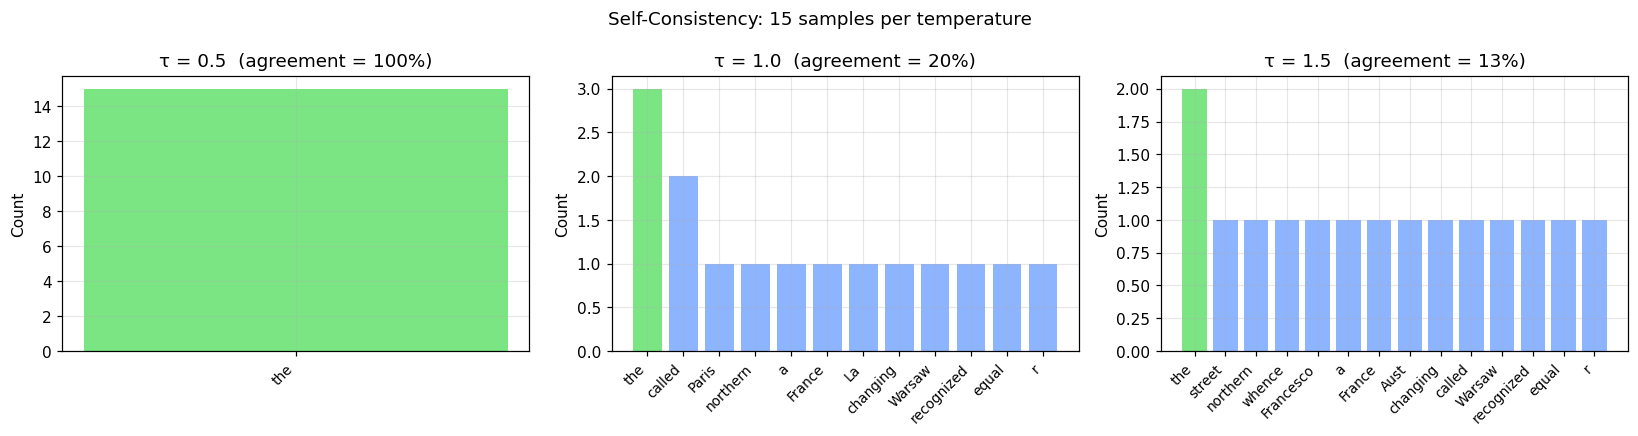


Low temperature → high agreement (less diversity, less error correction)
High temperature → low agreement (more diversity, better for hard problems)
Self-consistency works best when the task has a unique correct answer.


In [7]:
sc_prompt = "The capital of France is"
sc_ids = tokenizer.encode(sc_prompt, return_tensors="pt")

N_samples = 15
temperatures_sc = [0.5, 1.0, 1.5]
results_by_temp = {}

for tau in temperatures_sc:
    answers = []
    for i in range(N_samples):
        with torch.no_grad():
            logits_sc = model_base(sc_ids).logits[0, -1].float()
        probs_sc = torch.softmax(logits_sc / tau, dim=-1)
        # Sample a single next token
        torch.manual_seed(42 + i)
        next_id = torch.multinomial(probs_sc, 1).item()
        tok = tokenizer.decode(next_id).strip()
        answers.append(tok)
    results_by_temp[tau] = answers

# Display results
print(f"=== Self-Consistency: '{sc_prompt}' ===\n")
print(f"{'τ':<6} {'Samples':<60} {'Majority vote':<15} {'Agreement'}")
print("-" * 100)
for tau in temperatures_sc:
    ans = results_by_temp[tau]
    counts = Counter(ans)
    majority = counts.most_common(1)[0]
    agreement = majority[1] / len(ans)
    sample_str = ", ".join(ans[:10]) + ("..." if len(ans) > 10 else "")
    print(f"{tau:<6} {sample_str:<60} {majority[0]:<15} {agreement:.0%}")

# Visualization: agreement vs temperature
fig, axes = plt.subplots(1, len(temperatures_sc), figsize=(15, 4))
for ax, tau in zip(axes, temperatures_sc):
    counts = Counter(results_by_temp[tau])
    labels, vals = zip(*counts.most_common())
    colors_sc = ["#7ae582" if l == counts.most_common(1)[0][0] else "#8db4ff" for l in labels]
    ax.bar(range(len(labels)), vals, color=colors_sc)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Count")
    agreement = counts.most_common(1)[0][1] / N_samples
    ax.set_title(f"τ = {tau}  (agreement = {agreement:.0%})")

fig.suptitle(f"Self-Consistency: {N_samples} samples per temperature", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nLow temperature → high agreement (less diversity, less error correction)")
print(f"High temperature → low agreement (more diversity, better for hard problems)")
print(f"Self-consistency works best when the task has a unique correct answer.")


# Prompt Brittleness

The examples above might suggest that prompt engineering is a precise, predictable craft. It is not. Prompts are brittle, and the failure modes are worth cataloguing.

## Known Fragilities

| Fragility | Example | Why it happens |
|-----------|---------|---------------|
| **Order sensitivity** | Swapping the order of few-shot examples changes the answer | Recency bias in attention; later tokens have stronger causal influence |
| **Format sensitivity** | Adding or removing a newline changes classification accuracy | Tokenizer splits change, altering the hidden-state trajectory |
| **Label sensitivity** | Using "positive/negative" vs "good/bad" changes ICL accuracy | Different tokens activate different pretraining associations |
| **Instruction fragility** | "Classify the sentiment" vs "What is the sentiment?" | Slight rephrasing shifts which pretraining distribution is matched |
| **Majority label bias** | If most few-shot examples are positive, the model predicts positive | The model infers a base-rate from the context |

Min et al. (2022) showed a striking result: in many ICL settings, the *format and label space* of the examples matter more than the *correctness* of the labels. The model is often learning the task structure from the prompt template, not from the input-output mapping.

## Practical Mitigations

- **Ensemble over prompt variants**: run the same query with different wordings and aggregate.
- **Calibrate**: measure the model's prior bias on a neutral prompt, then subtract it.
- **Structured output**: constrain the output format (e.g., JSON schema) to reduce ambiguity.
- **Few-shot with balanced labels**: ensure the example set does not introduce a majority-class bias.
- **Temperature > 0 + self-consistency**: diversity across samples can compensate for prompt-level fragility.

The deeper lesson is that prompt engineering is not a substitute for evaluation. A prompt that works on five test cases may fail on the sixth. Without a proper evaluation loop, you are optimising in the dark.


# Extended Thinking and the Bridge to Agents

## Limits of Reasoning-Time Compute

The techniques in this notebook (CoT, self-consistency) all spend more tokens at inference time in exchange for better answers. But there are limits:

- **Diminishing returns**: going from 1 to 5 CoT samples helps dramatically; going from 50 to 100 helps marginally.
- **Cost scaling**: self-consistency with $N=20$ costs 20× a single call. For latency-sensitive applications, this is prohibitive.
- **Systematic errors**: if the model has a fundamental misconception, more reasoning amplifies it.
- **Verification bottleneck**: without a good verifier, more candidates just means more plausible-but-wrong answers to sort through.

## Trajectory Search

A more structured alternative is **trajectory search**: instead of treating each reasoning chain as an indivisible object, intervene earlier by exploring, scoring, and pruning reasoning paths while they are still unfolding. Tree of Thoughts (Yao et al., 2023) extends CoT from a single chain to a branching search tree; the generator-verifier pattern generates $N$ complete candidates and selects the best using a scoring function (the model's own log-probability, a reward model, or a deterministic check like a test suite).

These approaches sit on the continuum between pure prompting and full agency. Once the model can choose *which* branch to explore, evaluate *whether* the result is good, and decide *what to try next*, we are no longer studying a language model in isolation.

## The ReAct Bridge

**ReAct** (Yao et al., 2022) is the point where reasoning-time compute starts to look like agency. In ReAct, the model alternates between:

- **Thought**: a CoT reasoning step (reasoning-time compute).
- **Action**: a tool call (agent action).
- **Observation**: the tool result (environment feedback).

This is chain-of-thought with grounding. The model is no longer reasoning in a sealed textual chamber; it can act, look, and revise. That is why ReAct is the natural bridge to the companion notebook. Once thoughts can trigger actions and observations can reshape the next thought, we are no longer studying only a language model. We are studying the beginnings of an agentic loop.

> The next notebook, [How Agents Work](agents_how_they_work.ipynb), builds on this foundation to cover agent architectures, tool use, orchestration, memory, security, evaluation, and a full capstone implementation.


# Diagnostics, Limitations, and Open Problems

## Prompt-Level Failure Modes

| Failure | Root Cause | Mitigation |
|---------|-----------|------------|
| **Prompt injection** | Model cannot distinguish user input from instructions | Input sanitisation, system/user role separation |
| **Hallucinated reasoning** | CoT trace is fluent but factually wrong | Verification, self-consistency, grounding |
| **Faithfulness gap** | Stated reasoning does not reflect actual computation | Mechanistic interpretability, probing |
| **Context overflow** | Long prompts push critical information beyond attention span | Chunking, retrieval-augmented generation |
| **Format collapse** | Overconstrained prompts cause the model to produce degenerate output | Relax constraints, increase temperature |

## Open Problems (as of April 2026)

1. **Faithfulness of CoT**: models can produce reasoning chains that don't reflect their actual computation path.
2. **Optimal prompt selection**: there is no principled method for choosing the best prompt for a given task without trial and error.
3. **Sensitivity**: small prompt perturbations can cause large output changes, and we lack theoretical tools to predict when this will happen.
4. **Calibration**: model confidence (as expressed in token probabilities) is often poorly calibrated after RLHF/DPO.
5. **Compositionality**: prompts that work individually may interfere when combined (e.g., "be concise" + "explain step by step").


# Reproducibility

This notebook requires **PyTorch** and **Hugging Face Transformers** in addition to the standard numerical stack. The first run downloads SmolLM2-135M base model weights (~270 MB). No API keys or GPU are required. All inference runs on CPU.

**To export:**

```bash
python scripts/export_notebook.py --notebook prompt_engineering_how_they_work.ipynb --output-dir exports
```

**Companion notebooks:** [How LLMs Work](llms_how_they_work.ipynb) covers the architecture and inference pipeline. [How Agents Work](agents_how_they_work.ipynb) covers agent architectures, tool use, orchestration, memory, security, evaluation, and a capstone implementation. [Retrieval-Augmented Generation](rag_how_they_work.ipynb) covers embeddings, vector search, chunking, RAG pipelines, and evaluation.


In [8]:
import platform
print(f"Platform:      {platform.platform()}")
print(f"Python:        {sys.version}")
print(f"NumPy:         {np.__version__}")
print(f"Pandas:        {pd.__version__}")
print(f"Matplotlib:    {plt.matplotlib.__version__}")
print(f"Seaborn:       {sns.__version__}")
print(f"PyTorch:       {torch.__version__}")
print(f"Transformers:  {_tf.__version__}")


Platform:      Windows-10-10.0.26200-SP0
Python:        3.11.14 | packaged by conda-forge | (main, Jan 26 2026, 23:39:55) [MSC v.1944 64 bit (AMD64)]
NumPy:         2.1.3
Pandas:        3.0.0
Matplotlib:    3.10.8
Seaborn:       0.13.2
PyTorch:       2.11.0+cpu
Transformers:  5.6.2


# References

1. Brown, T., Mann, B., Ryder, N., et al. (2020). *Language Models are Few-Shot Learners*. [arXiv:2005.14165](https://arxiv.org/abs/2005.14165)
2. Wei, J., Wang, X., Schuurmans, D., et al. (2022). *Chain-of-Thought Prompting Elicits Reasoning in Large Language Models*. [arXiv:2201.11903](https://arxiv.org/abs/2201.11903)
3. Wang, X., Wei, J., Schuurmans, D., et al. (2022). *Self-Consistency Improves Chain of Thought Reasoning in Language Models*. [arXiv:2203.11171](https://arxiv.org/abs/2203.11171)
4. Yao, S., Yu, D., Zhao, J., et al. (2023). *Tree of Thoughts: Deliberate Problem Solving with Large Language Models*. [arXiv:2305.10601](https://arxiv.org/abs/2305.10601)
5. Yao, S., Zhao, J., Yu, D., et al. (2022). *ReAct: Synergizing Reasoning and Acting in Language Models*. [arXiv:2210.03629](https://arxiv.org/abs/2210.03629)
6. Olsson, C., Elhage, N., Nanda, N., et al. (2022). *In-context Learning and Induction Heads*. [arXiv:2209.11895](https://arxiv.org/abs/2209.11895)
7. Min, S., Lyu, X., Holtzman, A., et al. (2022). *Rethinking the Role of Demonstrations: What Makes In-Context Learning Work?* [arXiv:2202.12837](https://arxiv.org/abs/2202.12837)
8. Jurafsky, D. & Martin, J.H. (2026). *Speech and Language Processing*, 3rd ed. draft. [web.stanford.edu/~jurafsky/slp3/](https://web.stanford.edu/~jurafsky/slp3/)
9. Allal, L.B., Lozhkov, A., Penedo, G., et al. (2025). *SmolLM2: When Smol Goes Big*. [arXiv:2502.02737](https://arxiv.org/abs/2502.02737)


GitHub repository: [https://github.com/adamd1985/quant_research/blob/main/prompt_engineering_how_they_work.ipynb](https://github.com/adamd1985/quant_research/blob/main/prompt_engineering_how_they_work.ipynb)

Kaggle notebook available [here](https://www.kaggle.com/code/addarm/how-prompt-engineering-works)

# Media

All media used (in the form of code or images) are either solely owned by me, acquired through licensing, or part of the Public Domain and granted use through Creative Commons License.
